# Importing Modules

In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')

In [31]:
from google.colab import files
uploaded = files.upload()

Saving TESS Toronto emotional speech set data.zip to TESS Toronto emotional speech set data.zip


In [39]:
import zipfile

with zipfile.ZipFile('/content/TESS Toronto emotional speech set data.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/TESS Toronto emotional speech set data')


In [40]:
data_dir = '/content/TESS Toronto emotional speech set data'

# Load the Dataset

In [41]:
import os

paths = []
labels = []

for dirname, _, filenames in os.walk(data_dir):
    for filename in filenames:
        if filename.endswith('.wav'):
            paths.append(os.path.join(dirname, filename))
            label = filename.split('_')[-1].split('.')[0]
            labels.append(label.lower())

print(f'Dataset is Loaded: {len(paths)} files')



Dataset is Loaded: 5610 files


In [42]:
len(paths)

5610

In [43]:
paths[:5]

['/content/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/OAF_Fear/OAF_pike_fear.wav',
 '/content/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/OAF_Fear/OAF_late_fear.wav',
 '/content/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/OAF_Fear/OAF_beg_fear.wav',
 '/content/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/OAF_Fear/OAF_haze_fear.wav',
 '/content/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/OAF_Fear/OAF_youth_fear.wav']

In [44]:
labels[:5]

['fear', 'fear', 'fear', 'fear', 'fear']

In [45]:
## Create a dataframe
df = pd.DataFrame()
df['speech'] = paths
df['label'] = labels
df.head()

,speech,label
0,/content/TESS Toronto emotional speech set dat...,fear
1,/content/TESS Toronto emotional speech set dat...,fear
2,/content/TESS Toronto emotional speech set dat...,fear
3,/content/TESS Toronto emotional speech set dat...,fear
4,/content/TESS Toronto emotional speech set dat...,fear


In [46]:
df['label'].value_counts()

,count
label,
fear,800
ps,800
angry,800
neutral,800
disgust,800
happy,800
sad,800
disgust - copy,10


# Exploratory Data Analysis

<Axes: xlabel='label', ylabel='count'>

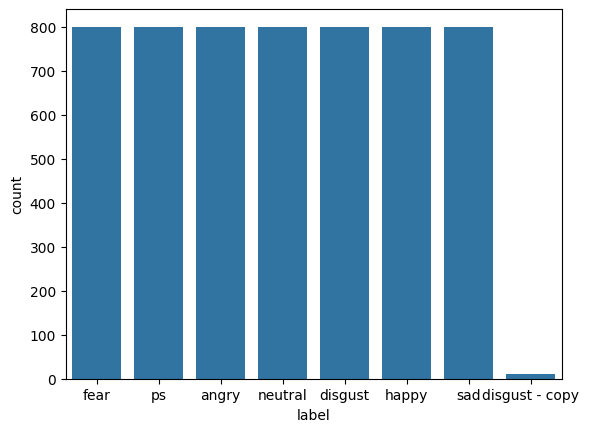

In [47]:
sns.countplot(data=df, x='label')

In [48]:
def waveplot(data, sr, emotion):
    plt.figure(figsize=(10,4))
    plt.title(emotion, size=20)
    librosa.display.waveshow(data, sr=sr)
    plt.show()

def spectogram(data, sr, emotion):
    x = librosa.stft(data)
    xdb = librosa.amplitude_to_db(abs(x))
    plt.figure(figsize=(11,4))
    plt.title(emotion, size=20)
    librosa.display.specshow(xdb, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar()

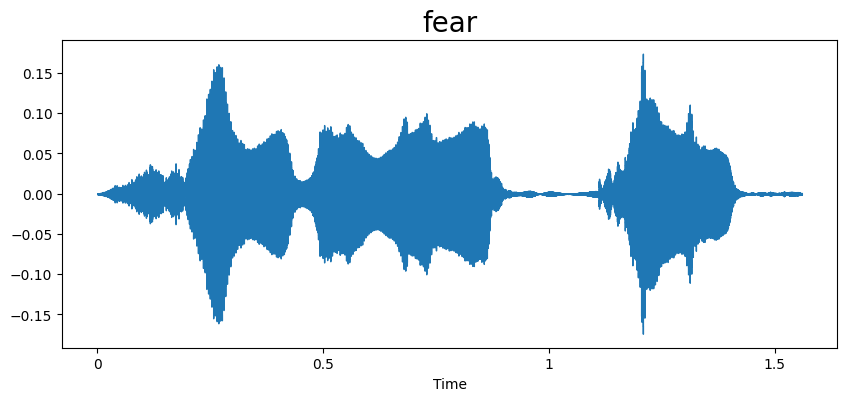

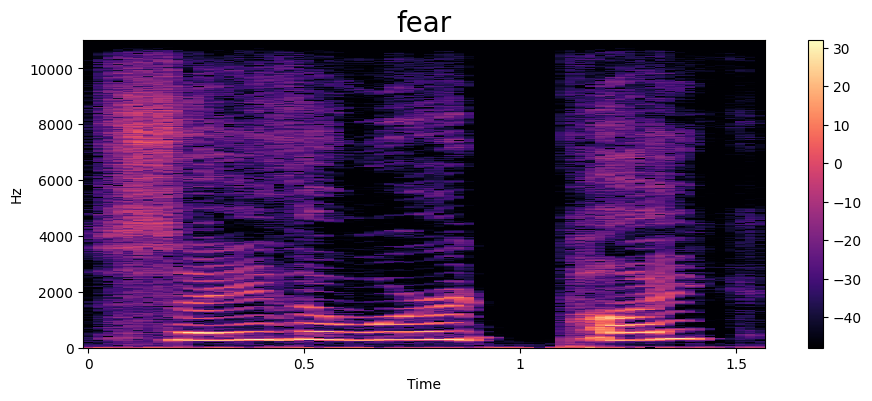

In [49]:
emotion = 'fear'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

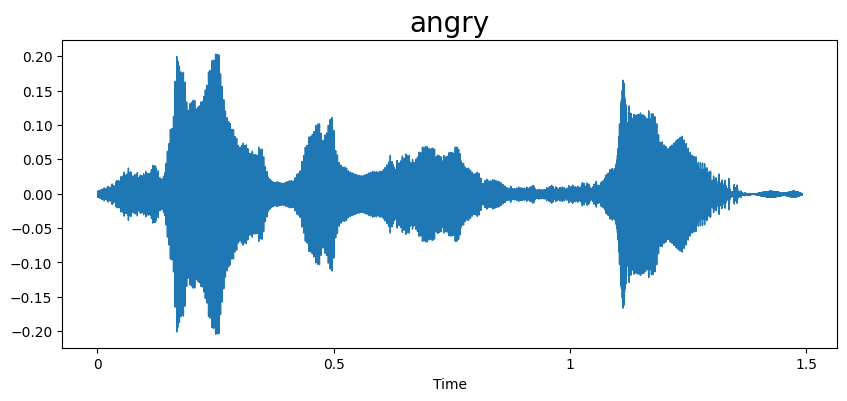

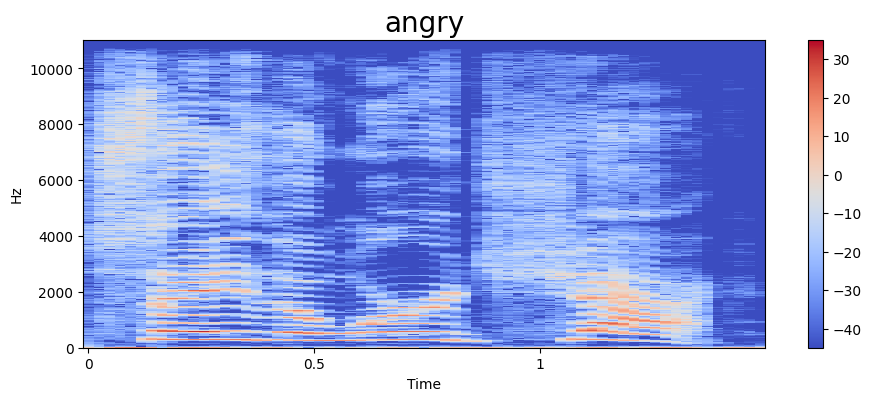

In [50]:
emotion = 'angry'
path = np.array(df['speech'][df['label']==emotion])[1]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

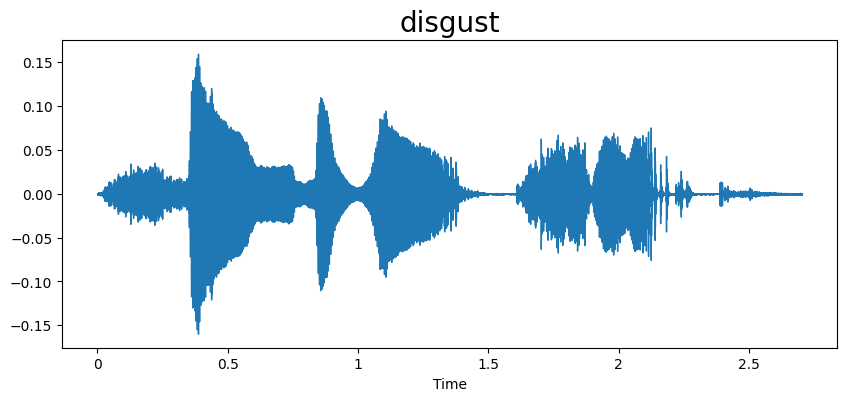

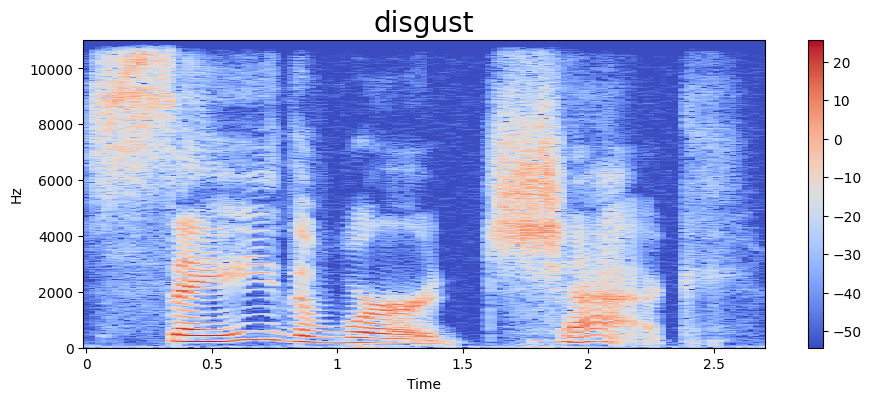

In [51]:
emotion = 'disgust'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

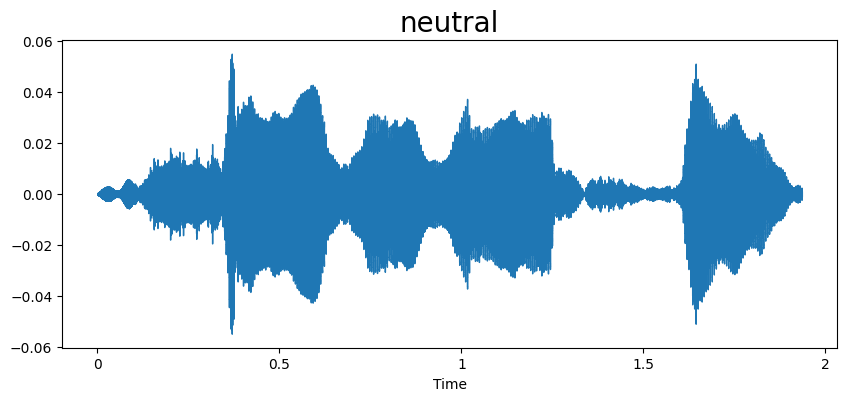

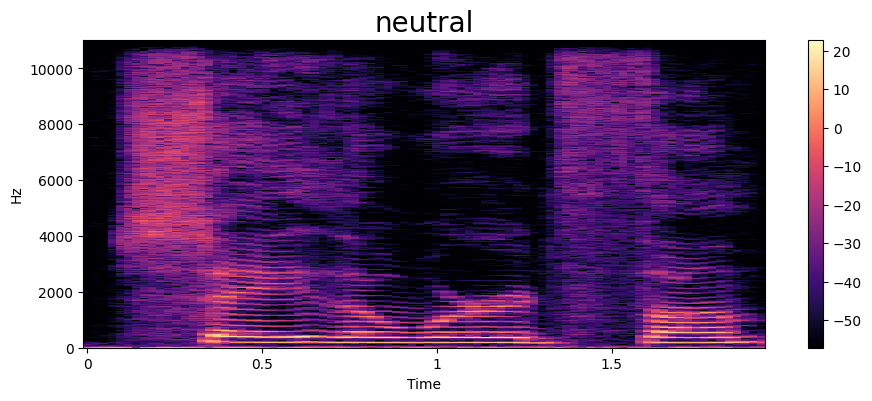

In [52]:
emotion = 'neutral'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

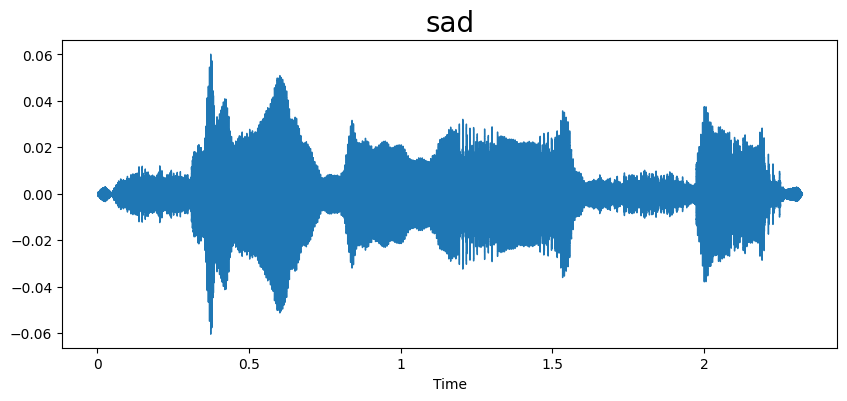

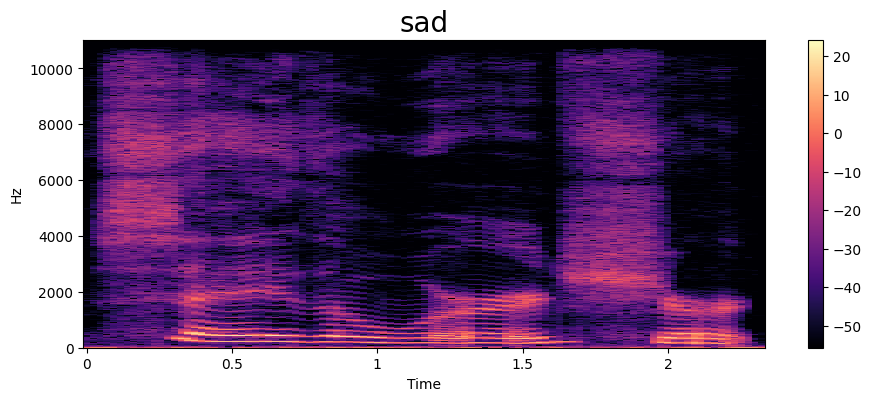

In [53]:
emotion = 'sad'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

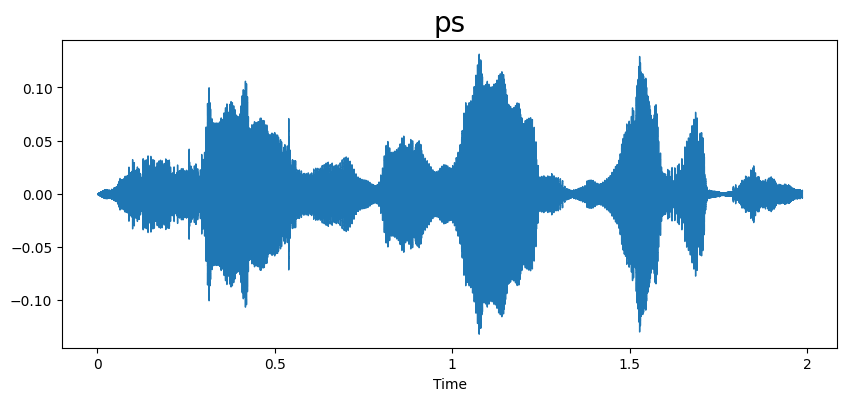

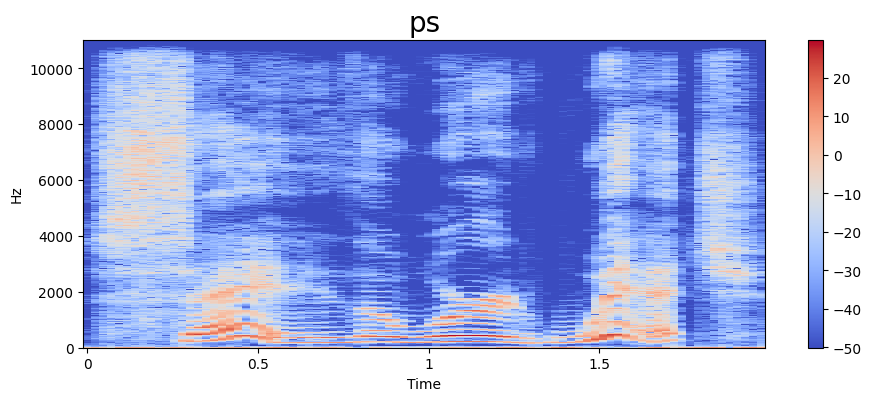

In [54]:
emotion = 'ps'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

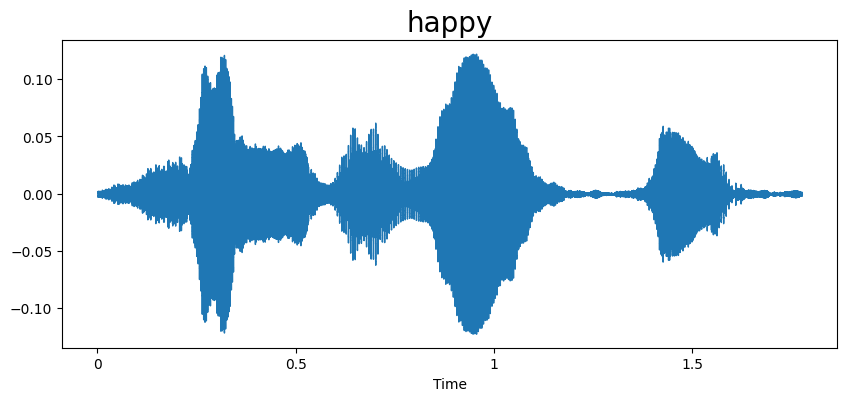

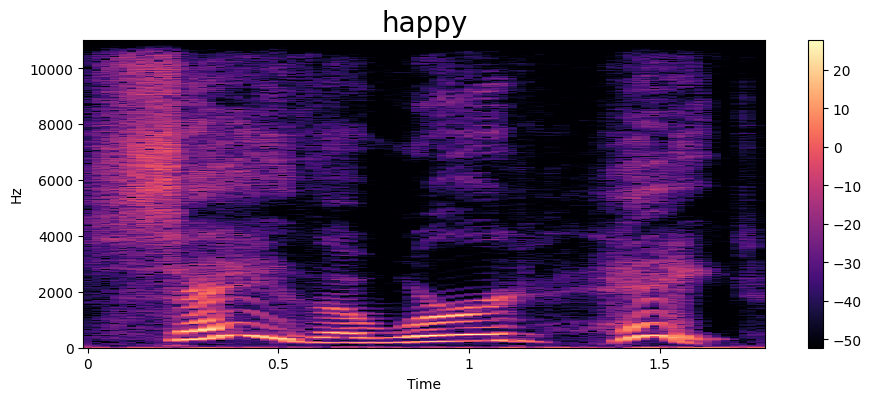

In [55]:
emotion = 'happy'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

# Feature Extraction

In [56]:
def extract_mfcc(filename):
    y, sr = librosa.load(filename, duration=3, offset=0.5)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    return mfcc

In [57]:
extract_mfcc(df['speech'][0])

array([-4.7188306e+02,  8.2361816e+01,  1.0358517e+01, -7.9805117e+00,
       -1.8290262e-01,  2.4408588e+00, -8.6530695e+00,  2.5632770e+00,
       -1.0594469e+01, -3.7612052e+00, -1.7147760e+01, -1.3951728e+00,
       -9.6579037e+00,  4.0783777e+00, -2.9702744e+00, -1.9875898e+00,
       -3.7005481e-01,  2.4360471e+00,  2.6474867e+00,  6.5708834e-01,
        1.2351725e+00,  1.1018339e+01,  1.5872792e+01,  2.2919323e+01,
        2.6273323e+01,  2.4195015e+01,  1.1066939e+01,  5.9662967e+00,
       -4.2916441e+00,  2.5075777e+00, -7.4885386e-01,  5.0076880e+00,
        2.5592721e+00, -5.7543082e+00, -3.1509969e+00,  4.0842581e+00,
       -8.8569051e-01,  3.2642410e+00, -4.6338048e+00,  2.4894904e-01],
      dtype=float32)

In [58]:
X_mfcc = df['speech'].apply(lambda x: extract_mfcc(x))

In [59]:
X_mfcc

,speech
0,"[-471.88306, 82.36182, 10.358517, -7.9805117, ..."
1,"[-456.0052, 74.894684, 12.581047, 0.01670834, ..."
2,"[-434.80698, 72.62281, 7.8739104, -9.481151, 1..."
3,"[-438.58746, 63.088135, 6.651155, 4.558683, 4...."
4,"[-453.43265, 53.22851, 14.091652, 0.62149894, ..."
...,...
5605,"[-328.36664, 44.600613, -14.2474785, 35.965908..."
5606,"[-331.7145, 52.132862, -17.142988, 14.884162, ..."
5607,"[-312.21655, 66.644394, -28.850216, 24.056618,..."
5608,"[-302.6353, 56.720577, -23.173166, 19.874756, ..."


In [60]:
X = [x for x in X_mfcc]
X = np.array(X)
X.shape

(5610, 40)

In [61]:
## input split
X = np.expand_dims(X, -1)
X.shape

(5610, 40, 1)

In [62]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
y = enc.fit_transform(df[['label']])

In [66]:
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [67]:
y.shape

(5610, 8)

# Create the LSTM Model

In [70]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

model = Sequential([
    LSTM(256, return_sequences=False, input_shape=(40,1)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(8, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 256)            │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,864 (1.17 MB)

 Trainable params: 305,864 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
# Train the model
history = model.fit(X, y, validation_split=0.2, epochs=25, batch_size=64)

Epoch 1/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.5353 - loss: 1.2759 - val_accuracy: 0.6319 - val_loss: 1.0118
Epoch 2/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 12s 175ms/step - accuracy: 0.8956 - loss: 0.3077 - val_accuracy: 0.9064 - val_loss: 0.3391
Epoch 3/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 20s 166ms/step - accuracy: 0.9336 - loss: 0.2209 - val_accuracy: 0.8788 - val_loss: 0.4143
Epoch 4/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 149ms/step - accuracy: 0.9431 - loss: 0.1900 - val_accuracy: 0.9430 - val_loss: 0.2618
Epoch 5/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 22s 173ms/step - accuracy: 0.9709 - loss: 0.0854 - val_accuracy: 0.9697 - val_loss: 0.1602
Epoch 6/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 20s 161ms/step - accuracy: 0.9714 - loss: 0.0914 - val_accuracy: 0.8779 - val_loss: 0.4677
Epoch 7/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 21s 174ms/step - accuracy: 0.9812 - loss: 0.0659 - val_accuracy: 0.9545 - val_loss: 0.1975
Epoch 8/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 20s 169ms/step - accuracy: 0.9736 - loss: 0.0773 - val_accu

# Plot the results

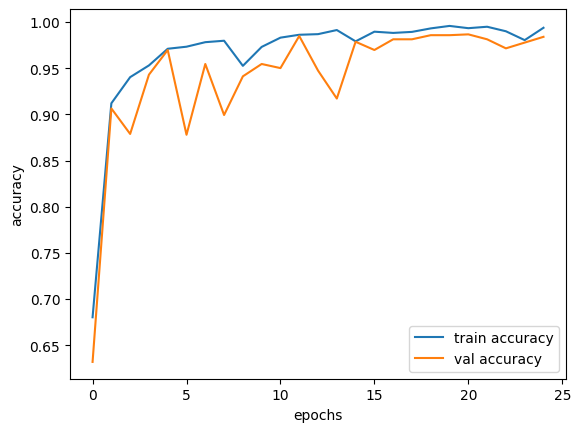

In [73]:
epochs = list(range(25))
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, label='train accuracy')
plt.plot(epochs, val_acc, label='val accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

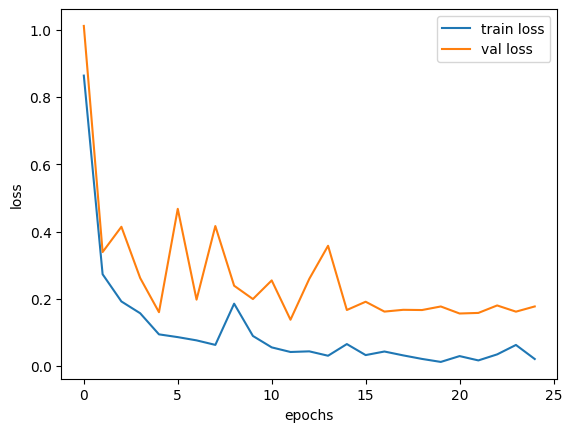

In [74]:
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(epochs, loss, label='train loss')
plt.plot(epochs, val_loss, label='val loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()